In [1]:
dir.create("../../results/mofa/figures/", showWarnings = FALSE, recursive = TRUE)
options(repr.plot.width = 9, repr.plot.height = 6, repr.plot.res = 150)
knitr::opts_chunk$set(warning = FALSE, message = FALSE)

## Overview

MOFA+ is a Bayesian latent factor model. It assumes that the observed data matrix for
each view **X_m** (features × samples) is generated by a shared set of latent factors
**Z** (factors × samples) through view-specific loading matrices **W_m** (features × factors):

```
X_m ≈ W_m · Z + noise_m
```

Inference is performed by maximising the ELBO (Evidence Lower BOund) — a variational
lower bound on the marginal likelihood. Automatic Relevance Determination (ARD) priors
on **W_m** drive uninformative factors to zero, effectively selecting the number of
active factors from the data.

**Why 10 factors?** For a cohort of ~200 CLL patients across 4 views, 10 factors
provides enough capacity to capture major sources of variation (IGHV status, trisomy 12,
treatment history, technical batches) while ARD pruning ensures unused factors are
set to zero variance.

---

## Setup

In [2]:
library(MOFA2)
library(ggplot2)
library(dplyr)
library(reticulate)   # Python bridge: delegates ELBO optimisation to mofapy2

theme_set(theme_bw(base_size = 12))

saved          <- readRDS("../../results/mofa/cll_data_preprocessed.RDS")
CLL_data       <- saved$data
CLL_covariates <- saved$covariates

cat("Views loaded:", paste(names(CLL_data), collapse = ", "), "\n")


Attaching package: ‘MOFA2’




The following object is masked from ‘package:stats’:

    predict





Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Views loaded: Drugs, Methylation, mRNA, Mutations 


---

## 1. Create MOFA Object

In [3]:
# create_mofa() accepts a named list of feature × sample matrices.
# It validates dimensions, aligns sample IDs across views, and builds
# the internal slot structure for options and training.
MOFAobject <- create_mofa(CLL_data)

# The print summary shows views, groups, samples per view, features per view.
# Samples absent from a view are treated as missing — no imputation needed.
print(MOFAobject)

Creating MOFA object from a list of matrices (features as rows, sample as columns)...




Untrained MOFA model with the following characteristics: 
 Number of views: 4 
 Views names: Drugs Methylation mRNA Mutations 
 Number of features (per view): 310 4248 5000 69 
 Number of groups: 1 
 Groups names: group1 
 Number of samples (per group): 200 
 


---

## 2. Data Options

In [4]:
data_opts <- get_default_data_options(MOFAobject)

# scale_views = TRUE: normalises each view to unit total variance before training.
# This is critical when views use different scales (log2-CPM mRNA vs 0-1 beta
# methylation values vs drug viability). Without scaling, the mRNA view
# (highest raw variance) would dominate all factor solutions.
data_opts$scale_views <- TRUE

print(data_opts)

$scale_views
[1] TRUE

$scale_groups
[1] FALSE

$center_groups
[1] TRUE

$use_float32
[1] TRUE

$views
[1] "Drugs"       "Methylation" "mRNA"        "Mutations"  

$groups
[1] "group1"



---

## 3. Model Options

In [5]:
model_opts <- get_default_model_options(MOFAobject)

# num_factors: Maximum factors the model may use.
# ARD priors will zero out inactive factors, so setting this higher than
# the true number of factors is safer than setting it too low.
# 10 is appropriate for a ~200-sample 4-view CLL cohort.
model_opts$num_factors <- 10

# likelihoods: Each view is modelled with the appropriate noise distribution.
#   mRNA        → Gaussian  (log2-CPM is approximately normal)
#   Methylation → Gaussian  (beta values 0-1 treated as continuous)
#   Drugs       → Gaussian  (viability AUC is continuous)
#   Mutations   → Bernoulli (binary presence/absence)
model_opts$likelihoods <- c(
  mRNA        = "gaussian",
  Methylation = "gaussian",
  Drugs       = "gaussian",
  Mutations   = "bernoulli"
)

print(model_opts)

$likelihoods
       mRNA Methylation       Drugs   Mutations 
 "gaussian"  "gaussian"  "gaussian" "bernoulli" 

$num_factors
[1] 10

$spikeslab_factors
[1] FALSE

$spikeslab_weights
[1] FALSE

$ard_factors
[1] FALSE

$ard_weights
[1] TRUE



---

## 4. Training Options

In [6]:
train_opts <- get_default_training_options(MOFAobject)

# convergence_mode controls the ELBO change threshold for stopping:
#   "fast"   ΔELBO% < 0.01%  — fast iteration, exploration
#   "medium" ΔELBO% < 0.001% — recommended for publication-quality results
#   "slow"   ΔELBO% < 0.0001%
train_opts$convergence_mode <- "medium"

# Seed for reproducible random initialisation of Z and W matrices
train_opts$seed    <- 42
train_opts$maxiter <- 1000
train_opts$verbose <- TRUE   # print ELBO at each iteration

print(train_opts)

$maxiter
[1] 1000

$convergence_mode
[1] "medium"

$drop_factor_threshold
[1] -1

$verbose
[1] TRUE

$startELBO
[1] 1

$freqELBO
[1] 5

$stochastic
[1] FALSE

$gpu_mode
[1] FALSE

$gpu_device
NULL

$seed
[1] 42

$outfile
NULL

$weight_views
[1] FALSE

$save_interrupted
[1] FALSE



---

## 5. Prepare MOFA Object

In [7]:
# prepare_mofa() validates all option combinations, pre-processes data
# (scaling, centering as specified), and locks the configuration.
# After this call the object is ready to pass to run_mofa().
MOFAobject <- prepare_mofa(
  MOFAobject,
  data_options     = data_opts,
  model_options    = model_opts,
  training_options = train_opts
)

print(MOFAobject)

Checking data options...



Checking training options...



Checking model options...



Untrained MOFA model with the following characteristics: 
 Number of views: 4 
 Views names: Drugs Methylation mRNA Mutations 
 Number of features (per view): 310 4248 5000 69 
 Number of groups: 1 
 Groups names: group1 
 Number of samples (per group): 200 
 


---

## 6. Train the Model

In [8]:
# run_mofa() calls mofapy2 (Python) via reticulate.
# use_basilisk = TRUE: basilisk automatically creates an isolated Python
# environment with the correct mofapy2 version — no manual Python setup needed.
#
# The outfile (.hdf5) persists the model to disk; load_model() can reload it.
# Training takes ~3-7 minutes on a modern laptop.

FORCE_RETRAIN <- FALSE
model_path    <- "../../results/mofa/CLL_MOFA_trained.hdf5"

if (!file.exists(model_path) || FORCE_RETRAIN) {
  MOFAobject_trained <- run_mofa(
    MOFAobject,
    outfile      = model_path,
    use_basilisk = TRUE
  )
  cat("Training complete. Model saved to:", model_path, "\n")
} else {
  # Load pre-trained model from HDF5 — skips re-training on subsequent runs
  MOFAobject_trained <- load_model(model_path)
  cat("Pre-trained model loaded from:", model_path, "\n")
}

print(MOFAobject_trained)

Connecting to the mofapy2 package using basilisk. 
    Set 'use_basilisk' to FALSE if you prefer to manually set the python binary using 'reticulate'.



+ /Users/yunhuazhu/Library/Caches/org.R-project.R/R/basilisk/1.14.3/0/bin/conda create --yes --prefix /Users/yunhuazhu/Library/Caches/org.R-project.R/R/basilisk/1.14.3/MOFA2/1.12.1/mofa_env 'python=3.10.5' --quiet -c conda-forge



+ /Users/yunhuazhu/Library/Caches/org.R-project.R/R/basilisk/1.14.3/0/bin/conda install --yes --prefix /Users/yunhuazhu/Library/Caches/org.R-project.R/R/basilisk/1.14.3/MOFA2/1.12.1/mofa_env 'python=3.10.5' -c conda-forge



+ /Users/yunhuazhu/Library/Caches/org.R-project.R/R/basilisk/1.14.3/0/bin/conda install --yes --prefix /Users/yunhuazhu/Library/Caches/org.R-project.R/R/basilisk/1.14.3/MOFA2/1.12.1/mofa_env -c conda-forge 'python=3.10.5' 'python=3.10.5' 'numpy=1.23.1' 'scipy=1.8.1' 'pandas=1.4.3' 'h5py=3.6.0' 'scikit-learn=1.1.1' 'dtw-python=1.2.2'



Training complete. Model saved to: ../../results/mofa/CLL_MOFA_trained.hdf5 


Trained MOFA with the following characteristics: 
 Number of views: 4 
 Views names: Drugs Methylation mRNA Mutations 
 Number of features (per view): 310 4248 5000 69 
 Number of groups: 1 
 Groups names: group1 
 Number of samples (per group): 200 
 Number of factors: 10 



---

## 7. Add Clinical Metadata

In [9]:
# Attaching clinical annotations enables factor-covariate association tests
# in Notebook 3. The metadata slot requires a 'sample' column matching
# the sample IDs used in the MOFA object.

model_samples <- samples_metadata(MOFAobject_trained)$sample

meta_df <- CLL_covariates |>
  tibble::rownames_to_column("sample") |>
  filter(sample %in% model_samples) |>
  mutate(
    # Numeric encoding for correlation tests:
    # 0 = Mutated (favourable), 1 = Unmutated (aggressive)
    IGHV_numeric  = ifelse(IGHV == "M", 0L, 1L),
    trisomy12_num = as.integer(trisomy12)
  )

samples_metadata(MOFAobject_trained) <- meta_df

cat("Metadata attached for", nrow(meta_df), "samples.\n")
cat("Variables:", paste(colnames(meta_df), collapse = ", "), "\n")

Metadata attached for 200 samples.


Variables: sample, IGHV, trisomy12, IGHV_numeric, trisomy12_num 


---

## 8. Convergence Check

Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_line()`).”


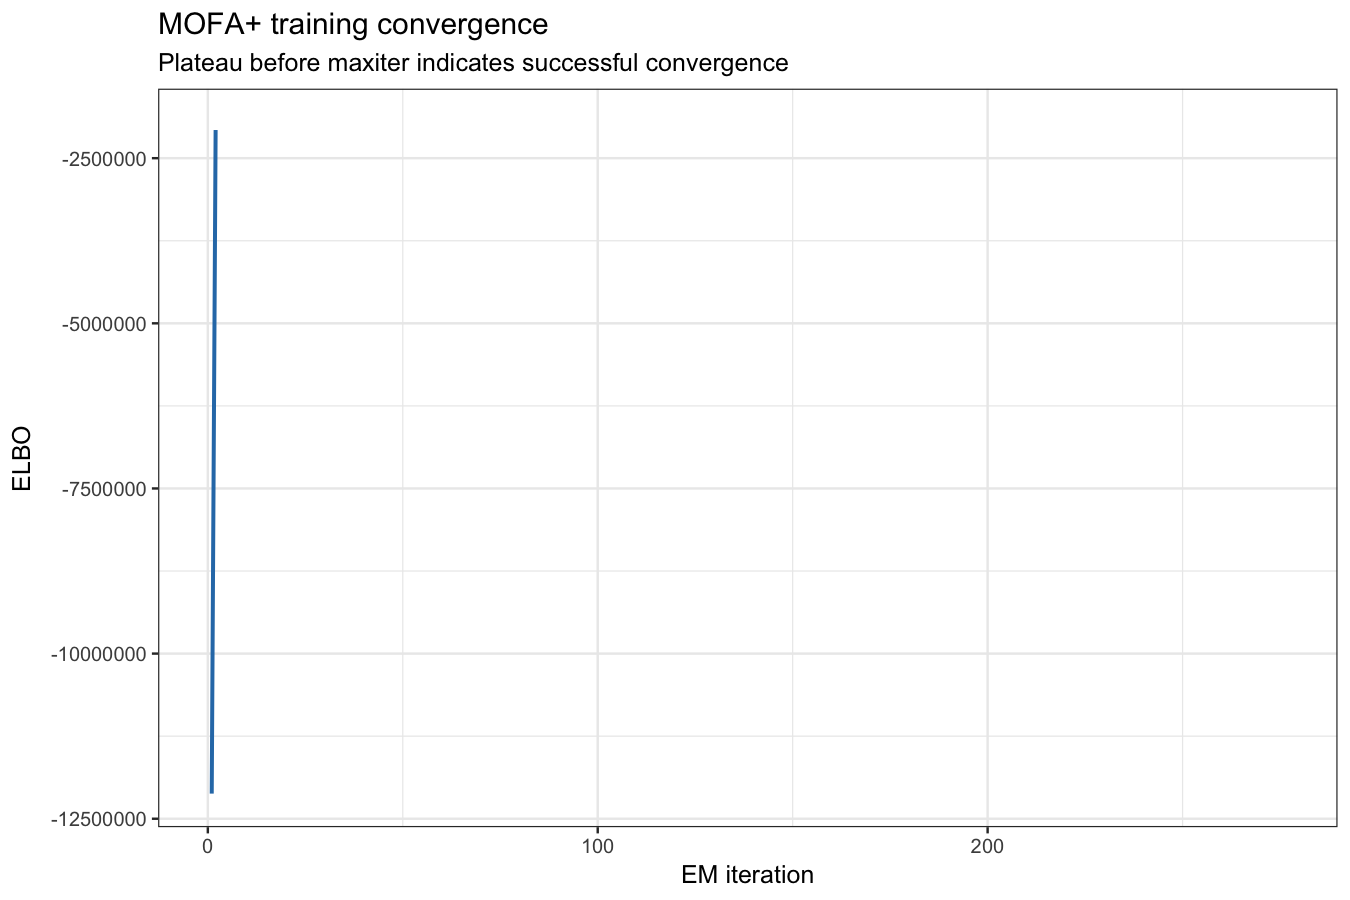

In [10]:
# A properly converged MOFA+ model shows the ELBO increasing monotonically
# and plateauing well before maxiter. A still-rising ELBO at maxiter suggests
# under-convergence — increase maxiter or switch to convergence_mode = "slow".

elbo <- MOFAobject_trained@training_stats$elbo

if (!is.null(elbo) && length(elbo) > 1) {
  data.frame(iteration = seq_along(elbo), ELBO = elbo) |>
    ggplot(aes(x = iteration, y = ELBO)) +
    geom_line(colour = "#2c7bb6", linewidth = 0.9) +
    labs(
      title    = "MOFA+ training convergence",
      subtitle = "Plateau before maxiter indicates successful convergence",
      x = "EM iteration", y = "ELBO"
    )
} else {
  message("ELBO trace not in loaded model. Set FORCE_RETRAIN=TRUE to capture it.")
}

---

## 9. Active Factors

In [11]:
# ARD priors drive uninformative factors to explain near-zero variance.
# Count factors that explain > 1% variance in at least one view.

r2  <- get_variance_explained(MOFAobject_trained)
r2_mat <- r2$r2_per_factor[[1]]   # samples group 1

active <- rownames(r2_mat)[apply(r2_mat, 1, max) > 0.01]
cat("Active factors (>1% R² in ≥1 view):", length(active), "\n")
cat("Factor IDs:", paste(active, collapse = ", "), "\n")

# Sanity check: the model should have ≤ num_factors active factors
stopifnot(length(active) <= model_opts$num_factors)

Active factors (>1% R² in ≥1 view): 10 


Factor IDs: Factor1, Factor2, Factor3, Factor4, Factor5, Factor6, Factor7, Factor8, Factor9, Factor10 


---

## 10. Save Annotated Model

In [12]:
saveRDS(MOFAobject_trained, "../../results/mofa/CLL_MOFA_annotated.RDS")
cat("Annotated model saved.\n")

Annotated model saved.


---

## Training Configuration Summary

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `num_factors` | 10 | Sufficient for ~200-sample 4-view CLL cohort; ARD prunes unused |
| `scale_views` | TRUE | Equalise variance across heterogeneous data types |
| mRNA likelihood | gaussian | log2(CPM+1) is approximately normal |
| Methylation likelihood | gaussian | Beta values as continuous |
| Drugs likelihood | gaussian | Viability AUC is continuous |
| Mutations likelihood | bernoulli | Binary somatic calls |
| `convergence_mode` | medium | ΔELBO% < 0.001% |
| `seed` | 42 | Reproducibility |

**→ Next: `03_factor_analysis.Rmd`**